# PRISM — Notebook 1
# Partitioned QAOA / MaxCut across every optimiser and every partition method

This notebook evaluates **partitioned QAOA circuits for MaxCut** along the two axes the PRISM paper raises:

1. **Variational optimisation** — solve MaxCut with QAOA using *as many classical optimisers as possible*
   (`COBYLA, Nelder-Mead, Powell, SLSQP, L-BFGS-B, CG, TNC, trust-constr, SPSA, GradientDescent,
   DifferentialEvolution`) and compare approximation ratio, evaluation budget, and convergence.
2. **Circuit partitioning** — cut the optimised QAOA circuit with **all eleven partition methods**
   (`Naive, Spectral, Louvain, Girvan-Newman, METIS, qdislib, PRISM-KL/OE/MI/BF/LCT`) and measure how
   faithfully the product reconstruction preserves the output distribution **and the recovered MaxCut
   objective** — the quantity a practitioner actually cares about.

Everything is exact statevector simulation. Heavy cells use a **cache-or-compute** helper: they load a
cached CSV if present (instant), otherwise they compute it from scratch. Set `RECOMPUTE=True` (or
`SCALE='full'`) to regenerate. Default scale is laptop-friendly (≤14 qubits).

In [2]:
# ── Setup ──
%matplotlib inline
import sys, os, time, math, json, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
for cand in ['../src', 'src', '.']:
    if os.path.isdir(os.path.join(cand, 'prism')):
        sys.path.insert(0, os.path.abspath(cand)); break
import prism
from prism import qml
from prism import METHOD_COLOURS, METHOD_ORDER

RESULTS = 'results'; os.makedirs(RESULTS, exist_ok=True)
SCALE = os.environ.get('PRISM_SCALE', 'small')   # 'small' (laptop) | 'full'
CFG = {
 'small': dict(opt_ns=[8], opt_seeds=[1], opt_p=[1, 2, 3, 4, 5, 6], maxiter=100, de_maxiter=8,
               part_ns=[8, 10, 12, 14], part_seeds=[19, 23], part_p=2, ix_opts=['COBYLA', 'Nelder-Mead', 'Powell', 'SLSQP', 'L-BFGS-B', 'CG', 'TNC', 'trust-constr', 'SPSA', 'GradientDescent', 'DifferentialEvolution']),
 'full':  dict(opt_ns=[8, 10], opt_seeds=[1, 2, 3], opt_p=[1, 2, 3, 4, 5, 6], maxiter=150, de_maxiter=45,
               part_ns=[8, 10, 12, 14], part_seeds=[19, 23, 29, 31], part_p=2,
               ix_opts=['COBYLA', 'SPSA', 'Powell', 'L-BFGS-B', 'Nelder-Mead']),
}[SCALE]
OPTIMIZERS = list(qml.OPTIMIZERS)
RECOMPUTE = os.environ.get('PRISM_RECOMPUTE', '0') == '1'
RECOMPUTE = 1

def cache_or_compute(path, fn, kind='csv', force=None):
    # Load <path> if present (fast); else compute via fn(), cache it, return.
    # Set RECOMPUTE=True (or env PRISM_RECOMPUTE=1) to always recompute.
    force = RECOMPUTE if force is None else force
    if (not force) and os.path.exists(path):
        return pd.read_csv(path) if kind == 'csv' else json.load(open(path))
    obj = fn()
    if kind == 'csv':
        obj.to_csv(path, index=False)
    else:
        json.dump(obj, open(path, 'w'))
    return obj

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
                     'font.size': 9.5, 'axes.titleweight': 'bold', 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.axisbelow': True})
print('prism', prism.__version__, '| qdislib present:', prism.has_real_qdislib())
print('optimizers:', OPTIMIZERS)
print('methods    :', METHOD_ORDER)
print('scale      :', SCALE)

prism 0.1.0 | qdislib present: False
optimizers: ['COBYLA', 'Nelder-Mead', 'Powell', 'SLSQP', 'L-BFGS-B', 'CG', 'TNC', 'trust-constr', 'SPSA', 'GradientDescent', 'DifferentialEvolution']
methods    : ['Naive', 'Spectral', 'Louvain', 'Girvan-Newman', 'METIS', 'qdislib', 'PRISM-KL', 'PRISM-OE', 'PRISM-MI', 'PRISM-BF', 'PRISM-LCT']
scale      : small


In [3]:
# ---- compute functions (each writes one cache file) ----
OV = {'DifferentialEvolution': CFG['de_maxiter'], 'trust-constr': max(20, CFG['maxiter'] // 2)}
N_qubits = 16
def compute_instance():
    g = qml.random_maxcut_graph(N_qubits, seed=44, kind='regular', degree=3)
    opt = qml.maxcut_brute_force(g, N_qubits)
    res = qml.optimize_qaoa(g, N_qubits, p=5, optimizer='COBYLA', seed=19, maxiter=CFG['maxiter'])
    layout = qml.maxcut_qaoa_layout(g, *qml.qaoa_split_params(res['x']))
    G = prism.build_interaction_graph(layout, N_qubits)
    qc, _ = prism.compile_circuit(layout, num_qubits=N_qubits)
    A, B = prism.partition('PRISM-LCT', G, layout, N_qubits, qc_full=qc, seed=19)
    return {'edges': [[int(u), int(v)] for u, v in g.edges()], 'opt': float(opt),
            'A': sorted(int(q) for q in A), 'B': sorted(int(q) for q in B),
            'energy': float(res['energy']), 'approx': float(res['approx_ratio']),
            'history': [float(x) for x in res['history']],
            'depth': prism.layout_depth(layout), 'gates': prism.layout_gate_count(layout)}

def compute_optimizers():
    rows = []
    for n in CFG['opt_ns']:
        for seed in CFG['opt_seeds']:
            g = qml.random_maxcut_graph(n, seed=seed, kind='regular', degree=3)
            for p in CFG['opt_p']:
                out = qml.run_all_optimizers(g, n, p=p, optimizers=OPTIMIZERS, seed=seed,
                                             maxiter=CFG['maxiter'], maxiter_overrides=OV)
                for name, r in out.items():
                    if 'error' in r:
                        continue
                    rows.append(dict(optimizer=name, n=n, seed=seed, p=p,
                                     approx_ratio=r['approx_ratio'], energy=r['energy'],
                                     optimal=r['optimal_cut'], nfev=r['nfev']))
    return pd.DataFrame(rows)

def compute_conv():
    n, seed, p = CFG['opt_ns'][0], CFG['opt_seeds'][0], max(CFG['opt_p'])
    g = qml.random_maxcut_graph(n, seed=seed, kind='regular', degree=3)
    out = qml.run_all_optimizers(g, n, p=p, optimizers=OPTIMIZERS, seed=seed,
                                 maxiter=CFG['maxiter'], maxiter_overrides=OV)
    conv = {}
    for name, r in out.items():
        if 'error' in r:
            continue
        conv[name] = list(np.maximum.accumulate(r['history']) / r['optimal_cut'])
    return conv

def compute_partitions():
    rows = []
    for n in CFG['part_ns']:
        for seed in CFG['part_seeds']:
            g = qml.random_maxcut_graph(n, seed=seed, kind='regular', degree=3)
            r = qml.optimize_qaoa(g, n, p=CFG['part_p'], optimizer='COBYLA', seed=seed,
                                  maxiter=CFG['maxiter'])
            prows, _ = qml.evaluate_qaoa_partitions(g, n, r['x'], seed=seed)
            for pr in prows:
                if pr.get('q_score') is None:
                    continue
                pr.update(n=n, seed=seed)
                rows.append(pr)
    return pd.DataFrame(rows)

def compute_interaction():
    n = CFG['part_ns'][0]
    g = qml.random_maxcut_graph(n, seed=CFG['part_seeds'][0], kind='regular', degree=3)
    rows = []
    for o in CFG['ix_opts']:
        r = qml.optimize_qaoa(g, n, p=CFG['part_p'], optimizer=o, seed=CFG['part_seeds'][0],
                              maxiter=CFG['maxiter'])
        prows, _ = qml.evaluate_qaoa_partitions(g, n, r['x'], seed=CFG['part_seeds'][0])
        for pr in prows:
            if pr.get('q_score') is not None:
                rows.append(dict(optimizer=o, method=pr['method'], q=pr['q_score']))
    return pd.DataFrame(rows)

# Load (or compute) every result table once.
inst   = cache_or_compute(f'{RESULTS}/nb1_instance.json', compute_instance, kind='json')
df_opt = cache_or_compute(f'{RESULTS}/nb1_optimizers.csv', compute_optimizers)
conv   = cache_or_compute(f'{RESULTS}/nb1_conv.json', compute_conv, kind='json')
df_part = cache_or_compute(f'{RESULTS}/nb1_partitions.csv', compute_partitions)
df_ix  = cache_or_compute(f'{RESULTS}/nb1_interaction.csv', compute_interaction)
print('optimizer runs:', len(df_opt), '| partition reconstructions:', len(df_part))

optimizer runs: 66 | partition reconstructions: 88


## 1. The problem: MaxCut and its QAOA ansatz

For a graph $G=(V,E,w)$ MaxCut seeks a bipartition $z\in\{0,1\}^n$ maximising
$C(z)=\sum_{(i,j)\in E} w_{ij}\,[z_i\neq z_j]$. The depth-$p$ QAOA ansatz prepares
$|\gamma,\beta\rangle = \prod_{\ell=1}^{p} e^{-i\beta_\ell H_M} e^{-i\gamma_\ell H_C}\,H^{\otimes n}|0\rangle$,
with cost $H_C=\sum_{(i,j)} w_{ij}\frac{1-Z_iZ_j}{2}$ and mixer $H_M=\sum_i X_i$. Each cost term is
`CNOT · RZ(2\gamma w) · CNOT`, so the **two-qubit interaction graph of the QAOA circuit equals the problem
graph** — which is why QAOA is the family where partition structure matters most.

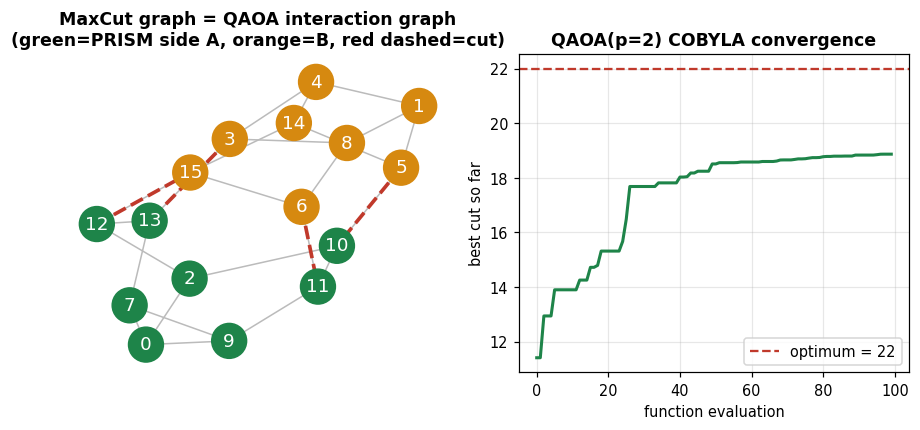

n=10 instance: |E|=24 optimum=22 QAOA approx-ratio=0.858 (depth 366, 456 gates)


In [4]:
# representative instance: problem graph + PRISM cut + QAOA convergence
import networkx as nx
g0 = nx.Graph(); g0.add_edges_from([tuple(e) for e in inst['edges']])
A0 = set(inst['A'])
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
pos = nx.spring_layout(g0, seed=1)
col = ['#1E8449' if q in A0 else '#D68910' for q in g0.nodes()]
nx.draw(g0, pos, ax=ax[0], node_color=col, with_labels=True, node_size=520,
        font_color='white', edge_color='#bbb')
cut_e = [(u, v) for u, v in g0.edges() if (u in A0) != (v in A0)]
nx.draw_networkx_edges(g0, pos, edgelist=cut_e, ax=ax[0], edge_color='#C0392B', width=2.4, style='dashed')
ax[0].set_title('MaxCut graph = QAOA interaction graph\n(green=PRISM side A, orange=B, red dashed=cut)')
ax[1].plot(np.maximum.accumulate(inst['history']), color='#1E8449', lw=2)
ax[1].axhline(inst['opt'], color='#C0392B', ls='--', label=f"optimum = {inst['opt']:.0f}")
ax[1].set_xlabel('function evaluation'); ax[1].set_ylabel('best cut so far')
ax[1].set_title('QAOA(p=2) COBYLA convergence'); ax[1].legend()
fig.tight_layout(); fig.savefig(f'{RESULTS}/nb1_f01_instance.png'); plt.show()
print(f"n=10 instance: |E|={g0.number_of_edges()} optimum={inst['opt']:.0f} "
      f"QAOA approx-ratio={inst['approx']:.3f} (depth {inst['depth']}, {inst['gates']} gates)")

## 2. Optimiser comparison on the full QAOA circuit

Approximation ratio and evaluation budget for every optimiser across the instance/depth grid.

In [5]:
df_opt.groupby('optimizer').agg(mean_ratio=('approx_ratio', 'mean'),
        mean_nfev=('nfev', 'mean')).sort_values('mean_ratio', ascending=False).round(3)

,mean_ratio,mean_nfev
optimizer,,
SLSQP,0.914,427.833
CG,0.913,1060.000
trust-constr,0.913,373.500
L-BFGS-B,0.911,475.833
DifferentialEvolution,0.905,1104.667
COBYLA,0.891,89.333
Powell,0.887,778.000
Nelder-Mead,0.883,144.000
TNC,0.876,817.333


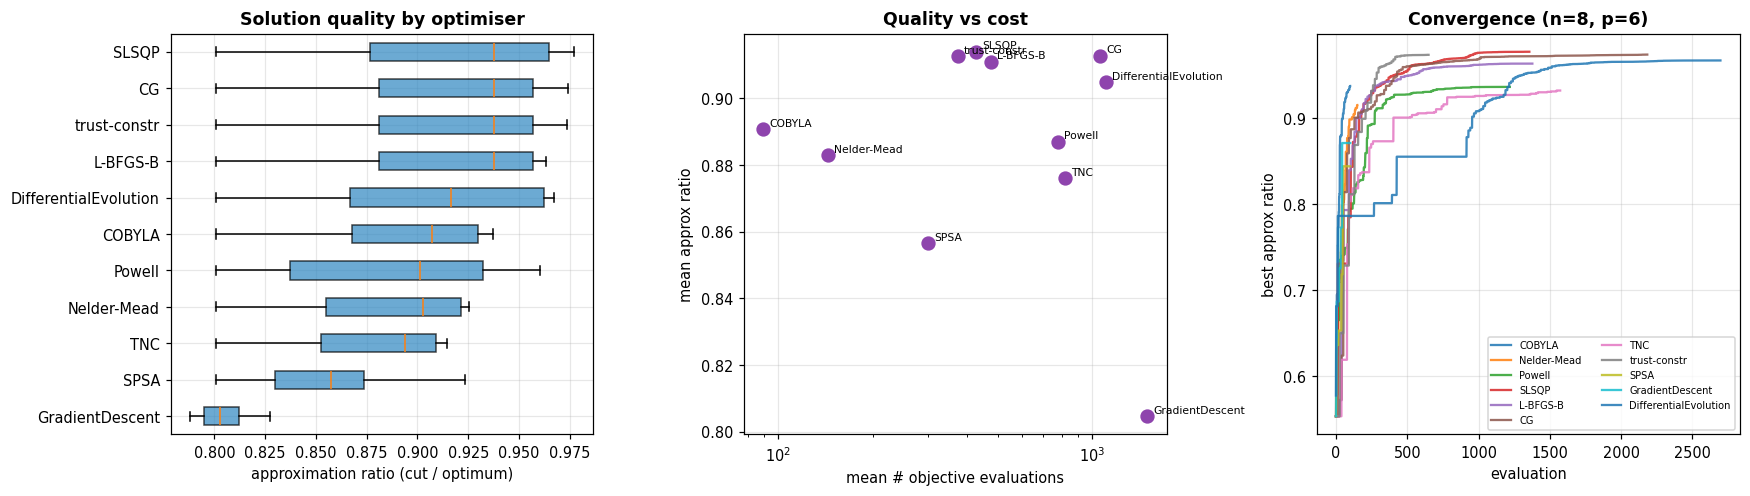

In [6]:
order = df_opt.groupby('optimizer').approx_ratio.mean().sort_values(ascending=False).index.tolist()
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
data = [df_opt[df_opt.optimizer == o].approx_ratio.values for o in order]
bp = ax[0].boxplot(data, vert=False, patch_artist=True, labels=order)
for patch in bp['boxes']:
    patch.set_facecolor('#2E86C1'); patch.set_alpha(0.7)
ax[0].set_xlabel('approximation ratio (cut / optimum)'); ax[0].set_title('Solution quality by optimiser')
ax[0].invert_yaxis()
mr = df_opt.groupby('optimizer').agg(r=('approx_ratio', 'mean'), f=('nfev', 'mean')).reindex(order)
ax[1].scatter(mr.f, mr.r, s=70, color='#8E44AD')
for o in order:
    ax[1].annotate(o, (mr.loc[o, 'f'], mr.loc[o, 'r']), fontsize=7, xytext=(4, 2), textcoords='offset points')
ax[1].set_xlabel('mean # objective evaluations'); ax[1].set_ylabel('mean approx ratio')
ax[1].set_title('Quality vs cost'); ax[1].set_xscale('log')
for name, c in conv.items():
    ax[2].plot(c, lw=1.5, label=name, alpha=0.85)
ax[2].set_xlabel('evaluation'); ax[2].set_ylabel('best approx ratio')
ax[2].set_title(f'Convergence (n={CFG["opt_ns"][0]}, p={max(CFG["opt_p"])})'); ax[2].legend(fontsize=6.5, ncol=2)
fig.tight_layout(); fig.savefig(f'{RESULTS}/nb1_f02_optimizers.png'); plt.show()

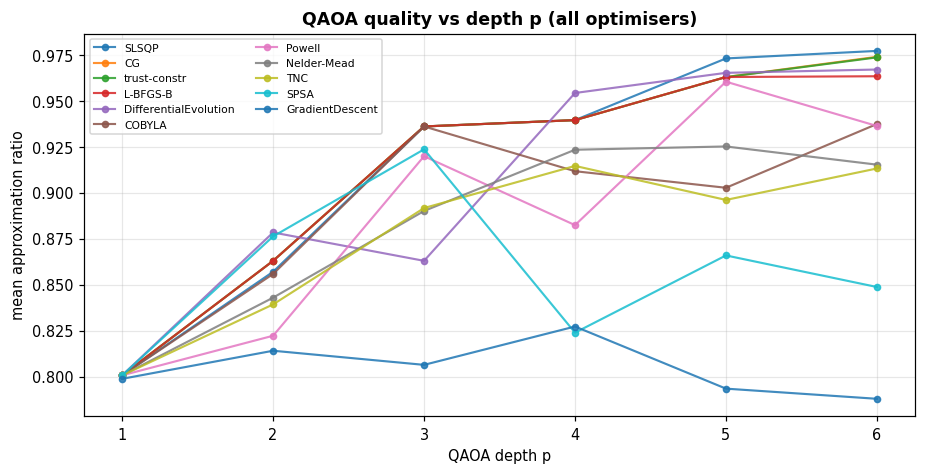

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
for o in order:
    s = df_opt[df_opt.optimizer == o].groupby('p').approx_ratio.mean()
    ax.plot(s.index, s.values, '-o', ms=4, lw=1.4, label=o, alpha=0.85)
ax.set_xlabel('QAOA depth p'); ax.set_ylabel('mean approximation ratio')
ax.set_xticks(sorted(df_opt.p.unique())); ax.set_title('QAOA quality vs depth p (all optimisers)')
ax.legend(fontsize=7, ncol=2)
fig.tight_layout(); fig.savefig(f'{RESULTS}/nb1_f03_depth.png'); plt.show()

## 3. Partitioning the optimised QAOA circuit — all eleven methods

For each cut we form the product reconstruction $\hat p = p_A\otimes p_B$ (cross gates dropped) and report
the unified **Q-Score**, the **recovered approximation ratio** $\mathbb{E}_{\hat p}[C]/C^\star$ vs ideal,
and the **cut-expectation error** $|\mathbb{E}_{\hat p}[C]-\mathbb{E}_{p}[C]|$ — does the partition preserve
the MaxCut objective?

In [8]:
present = [m for m in METHOD_ORDER if m in set(df_part.method)]
df_part.groupby('method').agg(Q=('q_score', 'mean'), TVD=('tvd', 'mean'),
        approx_recon=('approx_ratio_recon', 'mean'),
        cut_err=('cut_expectation_error', 'mean')).reindex(present).round(4)

,Q,TVD,approx_recon,cut_err
method,,,,
Naive,0.1348,0.8160,0.6199,3.1002
Spectral,0.3404,0.6649,0.6968,1.9462
Louvain,0.2957,0.7016,0.6812,2.1915
Girvan-Newman,0.3560,0.6528,0.6994,1.8913
METIS,0.3404,0.6649,0.6968,1.9462
qdislib,0.1770,0.7903,0.6179,3.0857
PRISM-KL,0.3187,0.6803,0.6802,2.2065
PRISM-OE,0.3412,0.6641,0.6952,1.9716
PRISM-MI,0.3496,0.6567,0.7012,1.8628


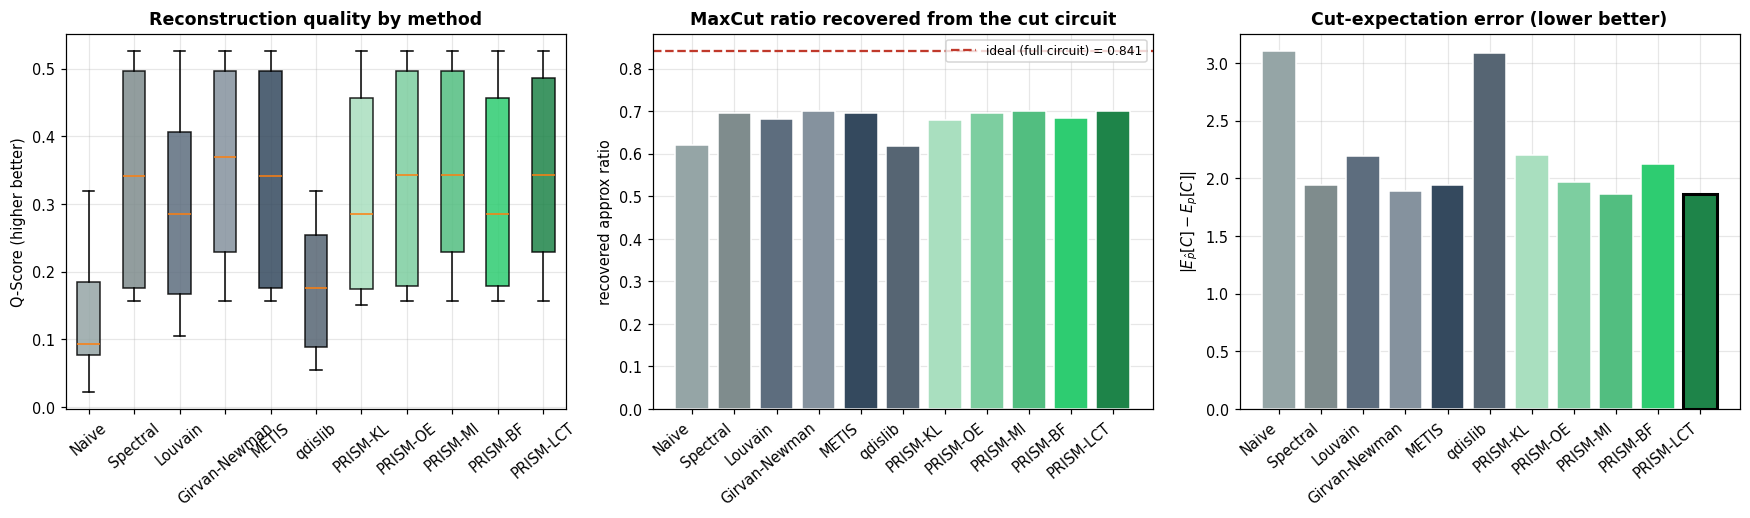

In [9]:
cols = [METHOD_COLOURS.get(m, '#333') for m in present]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
qd = [df_part[df_part.method == m].q_score.values for m in present]
bp = ax[0].boxplot(qd, patch_artist=True, labels=present)
for patch, c in zip(bp['boxes'], cols):
    patch.set_facecolor(c); patch.set_alpha(0.85)
ax[0].set_ylabel('Q-Score (higher better)'); ax[0].set_title('Reconstruction quality by method')
ax[0].tick_params(axis='x', rotation=40)
mean_ar = df_part.groupby('method').approx_ratio_recon.mean().reindex(present)
ideal_ar = df_part.approx_ratio_ideal.mean()
ax[1].bar(range(len(present)), mean_ar.values, color=cols, edgecolor='white')
ax[1].axhline(ideal_ar, color='#C0392B', ls='--', label=f'ideal (full circuit) = {ideal_ar:.3f}')
ax[1].set_xticks(range(len(present))); ax[1].set_xticklabels(present, rotation=40, ha='right')
ax[1].set_ylabel('recovered approx ratio'); ax[1].set_title('MaxCut ratio recovered from the cut circuit'); ax[1].legend(fontsize=8)
ce = df_part.groupby('method').cut_expectation_error.mean().reindex(present)
ax[2].bar(range(len(present)), ce.values, color=cols, edgecolor='white')
ax[2].set_xticks(range(len(present))); ax[2].set_xticklabels(present, rotation=40, ha='right')
ax[2].set_ylabel(r'$|E_{\hat p}[C]-E_p[C]|$'); ax[2].set_title('Cut-expectation error (lower better)')
ax[2].patches[present.index(ce.idxmin())].set_edgecolor('k'); ax[2].patches[present.index(ce.idxmin())].set_linewidth(2)
fig.tight_layout(); fig.savefig(f'{RESULTS}/nb1_f04_partition_quality.png'); plt.show()

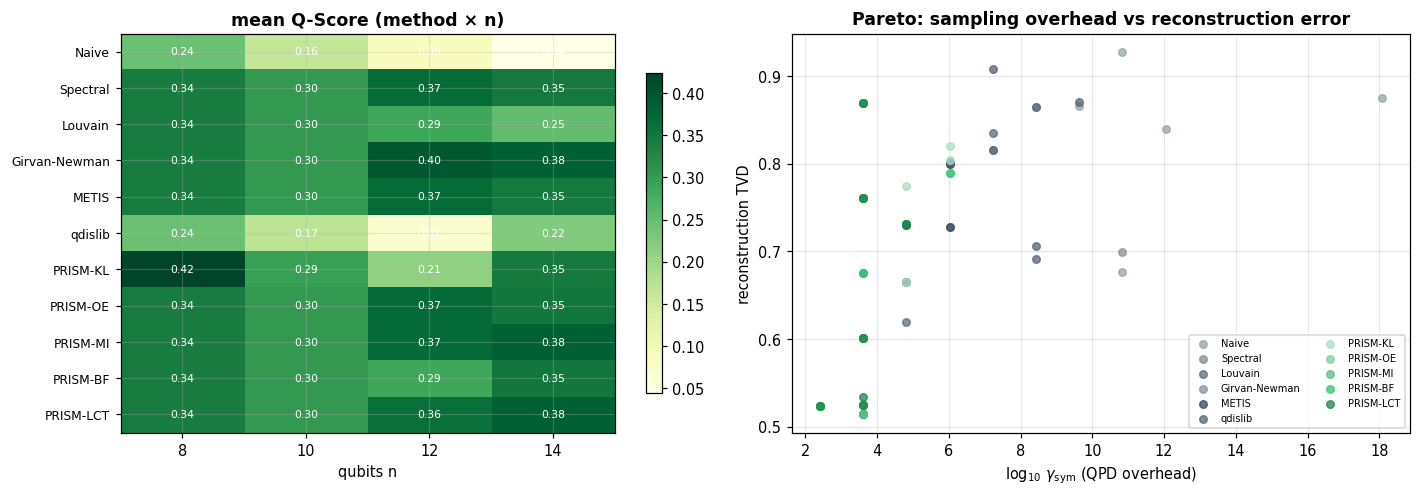

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
piv = df_part.pivot_table(index='method', columns='n', values='q_score', aggfunc='mean').reindex(present)
im = ax[0].imshow(piv.values, cmap='YlGn', aspect='auto')
ax[0].set_xticks(range(len(piv.columns))); ax[0].set_xticklabels(piv.columns)
ax[0].set_yticks(range(len(piv.index))); ax[0].set_yticklabels(piv.index, fontsize=8)
ax[0].set_xlabel('qubits n'); ax[0].set_title('mean Q-Score (method × n)')
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if np.isfinite(v):
            ax[0].text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                       color='black' if v > 0.5 else 'white')
fig.colorbar(im, ax=ax[0], shrink=0.8)
for m in present:
    s = df_part[df_part.method == m]
    ax[1].scatter(s['log10_gamma_sym'], s['tvd'], s=24, color=METHOD_COLOURS.get(m, '#333'), label=m, alpha=0.75)
ax[1].set_xlabel(r'$\log_{10}\,\gamma_{\mathrm{sym}}$ (QPD overhead)'); ax[1].set_ylabel('reconstruction TVD')
ax[1].set_title('Pareto: sampling overhead vs reconstruction error'); ax[1].legend(fontsize=6.5, ncol=2)
fig.tight_layout(); fig.savefig(f'{RESULTS}/nb1_f05_heatmap_pareto.png'); plt.show()